# CheXanatomy Model Inference
This notebook demonstrates how to use the trained CheXanatomy model for chest X-ray anatomy segmentation and analysis.

## Setup and Imports

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import requests
import re
from transformers import AutoProcessor, PaliGemmaForConditionalGeneration, PaliGemmaProcessor
from peft import PeftModel, PeftConfig
import torch
import os

# Add project path if needed
sys.path.append('/home/sgatidis/Projects/cheXanatomy')

# Force JAX to use CPU to avoid GPU memory conflicts
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

# Import VQVAE decoder utilities
try:
    import jax
    jax.config.update('jax_platform_name', 'cpu')
    from utils.VQVAE_decoder_utils import extract_objs
    print("✅ VQVAE decoder imported successfully")
except ImportError as e:
    print(f"⚠️ VQVAE decoder not available: {e}")
except Exception as e:
    print(f"⚠️ Error importing VQVAE decoder: {e}")

print("All imports successful!")

2026-01-22 21:08:42.365359: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✅ VQVAE decoder imported successfully
All imports successful!


## Load Your Fine-tuned CheXanatomy Model

In [14]:
# Run inference for all models and prompts
import os
from transformers import PaliGemmaForConditionalGeneration, PaliGemmaProcessor
from peft import PeftModel, PeftConfig
import torch

model_dir = "/home/sgatidis/data/chexanatomy/models/"
model_names = [
    "chexanatomy_paligemma_testrun_10B_448_H100",
    "chexanatomy_paligemma_testrun_10B_448_H100_single_structure",
    "chexanatomy_paligemma_testrun_10B_448_H100_single_structure_det_seg",
    "chexanatomy_paligemma_testrun_10B_448_H100_single_structure_tightBBox",
    "chexanatomy_paligemma_testrun_10B_H100"
]
prompts = [
    "segment heart",
    "segment right first rib",
    "segment right scapula",
    "segment left clavicle",
    "segment right atrium",
    "segment stomach"
]

base_model_id = "google/paligemma2-10b-pt-448"
device = "cuda" if torch.cuda.is_available() else "cpu"

results = {}

for model_name in model_names:
    model_path = os.path.join(model_dir, model_name)
    print(f"\n--- Running inference for model: {model_name} ---")
    try:
        base_model = PaliGemmaForConditionalGeneration.from_pretrained(base_model_id)
        adapter_config = PeftConfig.from_pretrained(model_path)
        model = PeftModel.from_pretrained(base_model, model_path)
        model = model.to(device)
        processor = PaliGemmaProcessor.from_pretrained(base_model_id)
    except Exception as e:
        print(f"Failed to load model {model_name}: {e}")
        continue
    model.eval()
    model_results = {}
    for prompt in prompts:
        print(f"Prompt: {prompt}")
        # TODO: Replace with actual image input as needed
        dummy_image = None  # Replace with your image loading logic
        try:
            inputs = processor(text=prompt, images=raw_image, return_tensors="pt").to(device)
            with torch.no_grad():
                output = model.generate(**inputs)
            decoded = processor.batch_decode(output, skip_special_tokens=True)
            print(f"Output: {decoded}")
            model_results[prompt] = decoded
        except Exception as e:
            print(f"Error running inference for prompt '{prompt}': {e}")
            model_results[prompt] = None
    results[model_name] = model_results
print("\nInference complete for all models.")


--- Running inference for model: chexanatomy_paligemma_testrun_10B_448_H100 ---


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Prompt: segment heart


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


...

Output: ['segment right scapula\n<loc0006><loc0000><loc0442><loc0295><seg040><seg040><seg077><seg127><seg021><seg049><seg039><seg040><seg073><seg117><seg074><seg012><seg016><seg052><seg089><seg012>']
Prompt: segment left clavicle


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Output: ['segment left clavicle\n<loc0006><loc0707><loc0185><loc1016><seg012><seg074><seg056><seg009><seg078><seg078><seg064><seg078><seg078><seg114><seg075><seg078><seg078><seg114><seg098><seg041>']
Prompt: segment right atrium


You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Output: ['segment right atrium\n<loc0392><loc0365><loc0686><loc0556><seg077><seg074><seg114><seg014><seg054><seg068><seg041><seg037><seg086><seg106><seg106><seg090><seg058><seg041><seg089><seg017>']
Prompt: segment stomach
Output: ['segment stomach\n<loc0820><loc0442><loc1020><loc0881><seg078><seg041><seg071><seg017><seg012><seg074><seg076><seg023><seg012><seg074><seg027><seg071><seg012><seg041><seg049><seg037>']

Inference complete for all models.


In [2]:
# Model configuration based on your config.yaml
base_model_id = "google/paligemma2-10b-pt-448"  # Based on your config: model_size: 10, input_image_size: 224
model_path = "/home/sgatidis/data/chexanatomy/models/chexanatomy_paligemma_testrun_10B_448_H100_single_structure_tightBBox"  # From your config

# Load the base model
print("Loading base model...")
base_model = PaliGemmaForConditionalGeneration.from_pretrained(base_model_id)

# Load the adapter configuration
print("Loading adapter configuration...")
adapter_config = PeftConfig.from_pretrained(model_path)

# Load the fine-tuned adapter into the base model
print("Loading fine-tuned adapter...")
model = PeftModel.from_pretrained(base_model, model_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

# Load the processor
processor = PaliGemmaProcessor.from_pretrained(base_model_id)

print("✅ CheXanatomy model loaded successfully!")

Loading base model...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading adapter configuration...
Loading fine-tuned adapter...


/home/sgatidis/miniforge3/envs/cheXanatomy/lib/python3.9/site-packages/torch/cuda/__init__.py:829: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ CheXanatomy model loaded successfully!


## Load Test Images

✅ Loaded image: /home/sgatidis/Projects/cheXanatomy/anatomy.jpg


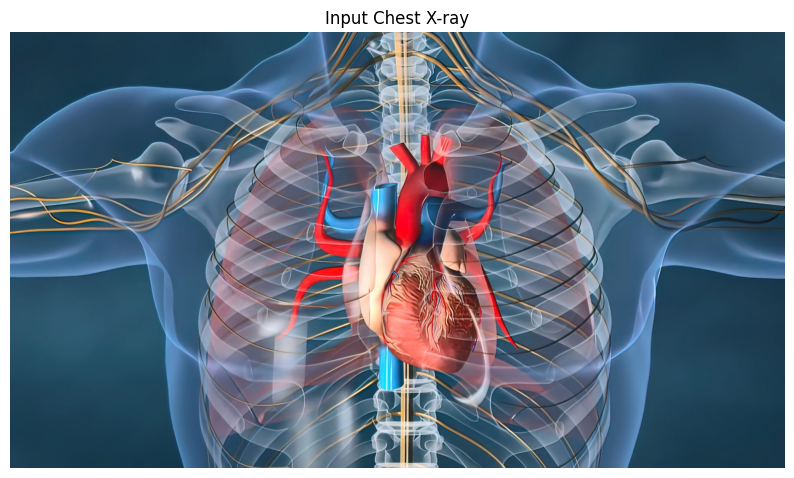

Image size: (2560, 1440)


In [23]:
# Load a test chest X-ray image
# You can replace this path with your own chest X-ray image
image_path = "/home/sgatidis/Projects/cheXanatomy/anatomy.jpg"  # Update this path

try:
    raw_image = Image.open(image_path).convert('RGB')
    print(f"✅ Loaded image: {image_path}")
except:
    # Try to load from CT_RATE training data as example
    try:
        import os
        ct_rate_path = "/home/sgatidis/data/chexanatomy/CT_RATE_training_data"
        # Find first .jpg or .png file in the directory
        for file in os.listdir(ct_rate_path)[:5]:  # Check first 5 files
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                sample_path = os.path.join(ct_rate_path, file)
                raw_image = Image.open(sample_path).convert('RGB')
                print(f"✅ Using sample from training data: {sample_path}")
                break
        else:
            raise FileNotFoundError("No image files found")
    except:
        # Create a placeholder if no image found
        print("❌ No images found. Creating placeholder.")
        print("Please update the image_path variable with your chest X-ray.")
        raw_image = Image.new('RGB', (224, 224), color='gray')

# Display the image
plt.figure(figsize=(10, 8))
plt.imshow(raw_image)
plt.title("Input Chest X-ray")
plt.axis('off')
plt.show()

print(f"Image size: {raw_image.size}")

## Run Inference - Anatomy Segmentation

In [ ]:
# Define prompts based on your training tasks from config.yaml
# Your model was trained on: detection, segmentation, multi_structure tasks, etc.
prompts = [
    "segment right lung",
    "segment left scapula", 
    "segment heart",
    "segment right lung ; left lung",        # Multi-structure segmentation
    "segment heart ; right lung",    
    "segment left first rib ; left second rib ; left third rib ; left fourth rib", # Multi-structure segmentation
    "segment left lung ; heart ; right lung", # Multi-structure segmentation
    "detect ribs",
    "identify anatomical orientation"
]

# Choose a prompt
prompt = prompts[1]  # Change index to try different prompts (5 = multi-structure)
print(f"Using prompt: '{prompt}'")

# Prepare inputs and move to the same device as the model
device = "cuda" if torch.cuda.is_available() else "cpu"
inputs = processor(raw_image, prompt, return_tensors="pt").to(device)

# Generate output
print("Generating response...")
with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=20, do_sample=True, temperature=0.7)

# Decode the result
result = processor.decode(output[0], skip_special_tokens=True)[len(prompt):]

print(f"Raw result: {result}")

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text. For this call, we will infer how many images each text has and add special tokens.


Using prompt: 'segment left scapula'
Generating response...


/home/sgatidis/miniforge3/envs/cheXanatomy/lib/python3.9/site-packages/transformers/generation/utils.py:2532: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cpu, whereas the model is on cuda. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cuda') before running `.generate()`.
  warnings.warn(


RuntimeError: Expected all tensors to be on the same device, but got index is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA__index_select)

## Visualize Results with Bounding Boxes

Found 4 location tokens: ['0087', '0603', '0314', '0843']
Bounding box coordinates: (1136, 188, 1588, 677)


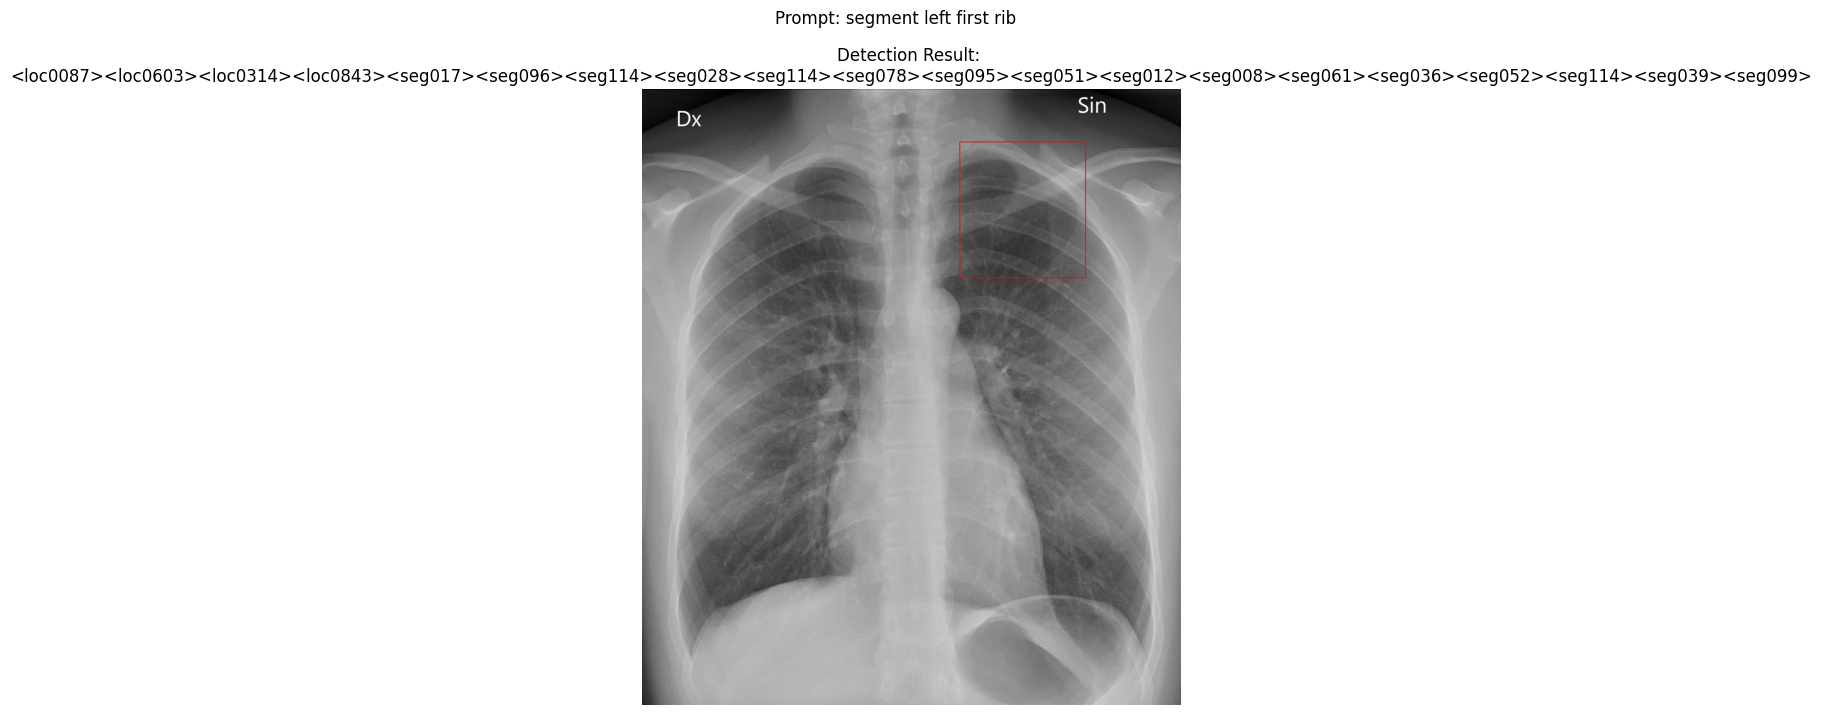

In [23]:
# Extract location tokens for bounding boxes
matches = re.findall(r'<loc(\d{4})>', result)
print(f"Found {len(matches)} location tokens: {matches}")

if len(matches) >= 4:
    # Convert to bounding box coordinates
    y1, x1, y2, x2 = [i / 1024 for i in map(int, matches[:4])]
    
    width, height = raw_image.size
    y1, x1, y2, x2 = map(round, (y1*height, x1*width, y2*height, x2*width))
    
    print(f"Bounding box coordinates: ({x1}, {y1}, {x2}, {y2})")
    
    # Draw bounding box
    image_with_bbox = raw_image.copy()
    draw = ImageDraw.Draw(image_with_bbox)
    draw.rectangle([x1, y1, x2, y2], outline="red", fill=None, width=3)
    
    # Display result
    plt.figure(figsize=(12, 8))
    plt.imshow(image_with_bbox)
    plt.title(f"Detection Result: {result}")
    plt.suptitle(f"Prompt: {prompt}")
    plt.axis('off')
    plt.show()
else:
    print("No bounding box coordinates found.")
    print(f"This might be a segmentation or descriptive response: {result}")

## Extract Segmentation Masks (if available)

Found 4 location tokens and 16 segmentation tokens
Using reconstructed token string for VQVAE decoding...
Found mask for 'None' with shape: (2207, 1929)


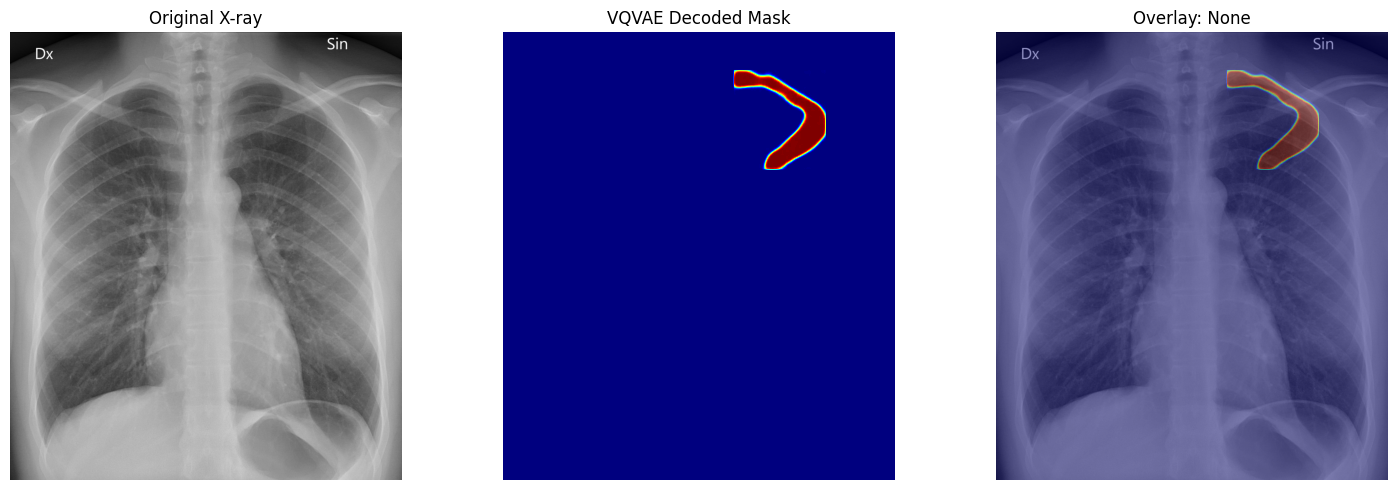

✅ Successfully extracted and visualized segmentation mask!
Bounding box: (1136, 188, 1588, 677)
Mask coverage: 100824/4257303 pixels (2.4%)


In [24]:
# Try to extract segmentation tokens and reconstruct mask
try:
    # Look for both location and segmentation tokens
    loc_matches = re.findall(r'<loc(\d{4})>', result)
    seg_matches = re.findall(r'<seg(\d+)>', result)
    
    print(f"Found {len(loc_matches)} location tokens and {len(seg_matches)} segmentation tokens")
    
    if seg_matches:
        try:
            # Reconstruct the full token string with both location and segmentation tokens
            reconstructed_tokens = ""
            
            # Add location tokens (required for proper parsing)
            for loc in loc_matches:
                reconstructed_tokens += f"<loc{loc}>"
            
            # Add segmentation tokens
            for seg in seg_matches:
                reconstructed_tokens += f"<seg{seg}>"
            
            print(f"Using reconstructed token string for VQVAE decoding...")
            
            # Get image dimensions
            width, height = raw_image.size
            
            # Extract segmentation objects from full tokens
            segmentation_objects = extract_objs(reconstructed_tokens, width, height)
            
            # Find the first object with a mask
            mask = None
            for obj in segmentation_objects:
                if 'mask' in obj and obj['mask'] is not None:
                    mask = obj['mask']
                    bbox = obj.get('xyxy', None)
                    name = obj.get('name', 'Unknown')
                    print(f"Found mask for '{name}' with shape: {mask.shape}")
                    break
            
            if mask is not None:
                # Convert to displayable format
                mask_display = (mask * 255).astype(np.uint8)
                
                # Create overlay visualization
                plt.figure(figsize=(15, 5))
                
                # Original image
                plt.subplot(1, 3, 1)
                plt.imshow(raw_image)
                plt.title("Original X-ray")
                plt.axis('off')
                
                # Segmentation mask
                plt.subplot(1, 3, 2)
                plt.imshow(mask_display, cmap='jet')
                plt.title("VQVAE Decoded Mask")
                plt.axis('off')
                
                # Overlay
                plt.subplot(1, 3, 3)
                plt.imshow(np.array(raw_image))
                plt.imshow(mask_display, cmap='jet', alpha=0.4)
                plt.title(f"Overlay: {name}")
                plt.axis('off')
                
                plt.tight_layout()
                plt.show()
                
                print("✅ Successfully extracted and visualized segmentation mask!")
                
                # Additional info
                if bbox:
                    print(f"Bounding box: {bbox}")
                print(f"Mask coverage: {np.count_nonzero(mask)}/{mask.size} pixels ({100*np.count_nonzero(mask)/mask.size:.1f}%)")
                
            else:
                print("No valid mask found in segmentation objects.")
                print(f"Segmentation objects: {len(segmentation_objects)}")
            
        except Exception as ve:
            print(f"Error in VQVAE decoding: {ve}")
            import traceback
            traceback.print_exc()
            print("Segmentation tokens found but cannot decode to mask.")
            print(f"Tokens: {seg_matches[:10]}...")  # Show first 10 tokens
            
    else:
        print("No segmentation tokens found in the response.")
        print("This might be a detection-only task or descriptive response.")
        
except Exception as e:
    print(f"Error processing segmentation: {e}")
    import traceback
    traceback.print_exc()

In [25]:
# Debug the segmentation objects structure
print("Debugging segmentation objects:")
print(f"Number of objects: {len(segmentation_objects)}")

for i, obj in enumerate(segmentation_objects):
    print(f"\nObject {i+1}:")
    print(f"  Type: {type(obj)}")
    print(f"  Keys: {obj.keys() if isinstance(obj, dict) else 'Not a dict'}")
    
    if isinstance(obj, dict):
        for key, value in obj.items():
            if key == 'mask':
                if value is not None:
                    print(f"    {key}: {type(value)} with shape {getattr(value, 'shape', 'no shape')}")
                    print(f"    Mask min/max: {getattr(value, 'min', lambda: 'no min')()}/{getattr(value, 'max', lambda: 'no max')()}")
                else:
                    print(f"    {key}: None")
            else:
                print(f"    {key}: {type(value)} = {value}")

# Try to access mask differently
print(f"\nOriginal segmentation tokens: {seg_matches}")
print(f"Segmentation token string: '{reconstructed_tokens}'")

# Let's also try to inspect the raw segmentation objects more deeply
if segmentation_objects:
    obj = segmentation_objects[0]
    if isinstance(obj, dict):
        # Look for any array-like data that might be the mask
        for key, value in obj.items():
            if hasattr(value, 'shape') or hasattr(value, '__array__'):
                try:
                    import numpy as np
                    arr = np.array(value) if not isinstance(value, np.ndarray) else value
                    print(f"\nArray found in '{key}': shape {arr.shape}, dtype {arr.dtype}")
                    print(f"  Min: {arr.min()}, Max: {arr.max()}")
                    print(f"  Non-zero elements: {np.count_nonzero(arr)}")
                except Exception as e:
                    print(f"Error processing {key}: {e}")

Debugging segmentation objects:
Number of objects: 1

Object 1:
  Type: <class 'dict'>
  Keys: dict_keys(['content', 'xyxy', 'mask', 'name'])
    content: <class 'str'> = <loc0087><loc0603><loc0314><loc0843><seg017><seg096><seg114><seg028><seg114><seg078><seg095><seg051><seg012><seg008><seg061><seg036><seg052><seg114><seg039><seg099>
    xyxy: <class 'tuple'> = (1136, 188, 1588, 677)
    mask: <class 'numpy.ndarray'> with shape (2207, 1929)
    Mask min/max: 0.0/1.0
    name: <class 'NoneType'> = None

Original segmentation tokens: ['017', '096', '114', '028', '114', '078', '095', '051', '012', '008', '061', '036', '052', '114', '039', '099']
Segmentation token string: '<loc0087><loc0603><loc0314><loc0843><seg017><seg096><seg114><seg028><seg114><seg078><seg095><seg051><seg012><seg008><seg061><seg036><seg052><seg114><seg039><seg099>'

Array found in 'mask': shape (2207, 1929), dtype float64
  Min: 0.0, Max: 1.0
  Non-zero elements: 100824


In [26]:
result

'\n<loc0087><loc0603><loc0314><loc0843><seg017><seg096><seg114><seg028><seg114><seg078><seg095><seg051><seg012><seg008><seg061><seg036><seg052><seg114><seg039><seg099>'

In [27]:
result = '\n<loc0071><loc0226><loc0300><loc0404><seg004><seg008><seg059><seg069><seg005><seg099><seg003><seg060><seg099><seg031><seg074><seg041><seg039><seg078><seg001><seg099>'

In [28]:
result

'\n<loc0071><loc0226><loc0300><loc0404><seg004><seg008><seg059><seg069><seg005><seg099><seg003><seg060><seg099><seg031><seg074><seg041><seg039><seg078><seg001><seg099>'

Attempting to fix VQVAE decoding...
Original result: 
<loc0071><loc0226><loc0300><loc0404><seg004><seg008><seg059><seg069><seg005><seg099><seg003><seg060><seg099><seg031><seg074><seg041><seg039><seg078><seg001><seg099>
Location tokens: ['0071', '0226', '0300', '0404']
Segmentation tokens: ['017', '096', '114', '028', '114', '078', '095', '051', '012', '008', '061', '036', '052', '114', '039', '099']
Reconstructed token string: <loc0071><loc0226><loc0300><loc0404><seg017><seg096><seg114><seg028><seg114><seg078><seg095><seg051><seg012><seg008><seg061><seg036><seg052><seg114><seg039><seg099>
Full parsing result: 1 objects
Object 1: dict_keys(['content', 'xyxy', 'mask', 'name'])
  Found mask with shape: (2207, 1929)


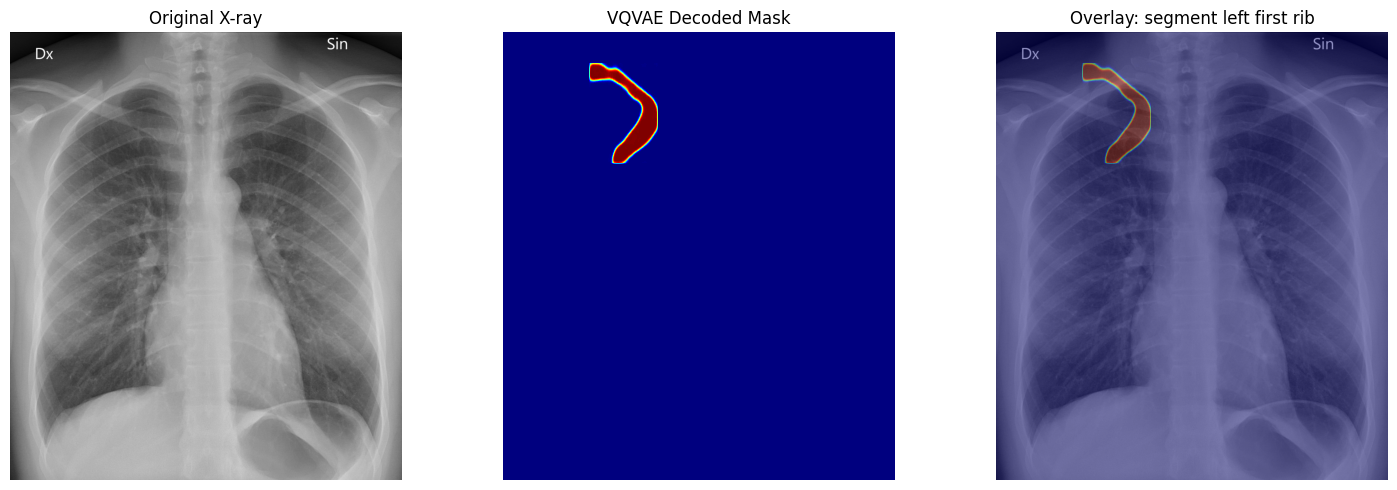

✅ Successfully decoded VQVAE mask!


In [29]:
# Try to fix the token parsing issue
print("Attempting to fix VQVAE decoding...")

# The issue might be that we need both location AND segmentation tokens together
# Let's check the original result for location tokens too
print(f"Original result: {result}")

# Look for location tokens
loc_matches = re.findall(r'<loc(\d{4})>', result)
print(f"Location tokens: {loc_matches}")
print(f"Segmentation tokens: {seg_matches}")

if loc_matches and seg_matches:
    # Reconstruct the full token string as it should appear
    reconstructed_tokens = ""
    
    # Add location tokens
    for loc in loc_matches:
        reconstructed_tokens += f"<loc{loc}>"
    
    # Add segmentation tokens  
    for seg in seg_matches:
        reconstructed_tokens += f"<seg{seg}>"
    
    print(f"Reconstructed token string: {reconstructed_tokens}")
    
    try:
        # Try with the full reconstructed token string
        width, height = raw_image.size
        full_objects = extract_objs(reconstructed_tokens, width, height)
        
        print(f"Full parsing result: {len(full_objects)} objects")
        
        for i, obj in enumerate(full_objects):
            print(f"Object {i+1}: {obj.keys()}")
            if 'mask' in obj and obj['mask'] is not None:
                print(f"  Found mask with shape: {obj['mask'].shape}")
                
                # Visualize this mask
                mask = obj['mask']
                mask_display = (mask * 255).astype(np.uint8)
                
                plt.figure(figsize=(15, 5))
                
                plt.subplot(1, 3, 1)
                plt.imshow(raw_image)
                plt.title("Original X-ray")
                plt.axis('off')
                
                plt.subplot(1, 3, 2)
                plt.imshow(mask_display, cmap='jet')
                plt.title("VQVAE Decoded Mask")
                plt.axis('off')
                
                plt.subplot(1, 3, 3)
                plt.imshow(np.array(raw_image))
                plt.imshow(mask_display, cmap='jet', alpha=0.4)
                plt.title(f"Overlay: {prompt}")
                plt.axis('off')
                
                plt.tight_layout()
                plt.show()
                
                print("✅ Successfully decoded VQVAE mask!")
                break
        else:
            print("❌ Still no valid mask found in full objects")
            
    except Exception as e:
        print(f"Error with full token reconstruction: {e}")
        import traceback
        traceback.print_exc()
        
else:
    print("Missing either location or segmentation tokens for full reconstruction")

## Multi-Structure Segmentation Processing

Detected multi-structure segmentation response!
Original result: 
<loc0100><loc0597><loc0458><loc0921><seg063><seg127><seg114><seg087><seg078><seg078><seg058><seg044><seg078><seg041><seg071><seg011><seg109><seg057><seg003><seg097> left second rib ; <loc0100><loc0597><loc0458><loc0918><seg063><seg127><seg114><seg087><seg078><seg078><seg058><seg044><seg078><seg041><seg071><seg011><seg005><seg114><seg003><seg098> left first rib ; <loc0142><loc0597><loc0510><loc0940><seg063><seg127><seg114><seg087><seg078><seg078><seg109><seg044><seg078><seg041><seg059><seg044><seg051><seg078><seg050><seg098> left third rib ; <loc0217><loc0597><loc0612><loc0959><seg063><seg127><seg114><seg087><seg078><seg114><seg109><seg011><seg078><seg074><seg059><seg057><seg078><seg114><seg005><seg077> left fourth rib
Found 4 structure responses

Processing structure 1: <loc0100><loc0597><loc0458><loc0921><seg063><seg127><seg114><seg087><seg078><seg078><seg058><seg044><seg078><seg041><seg071><seg011><seg109><seg057><seg0

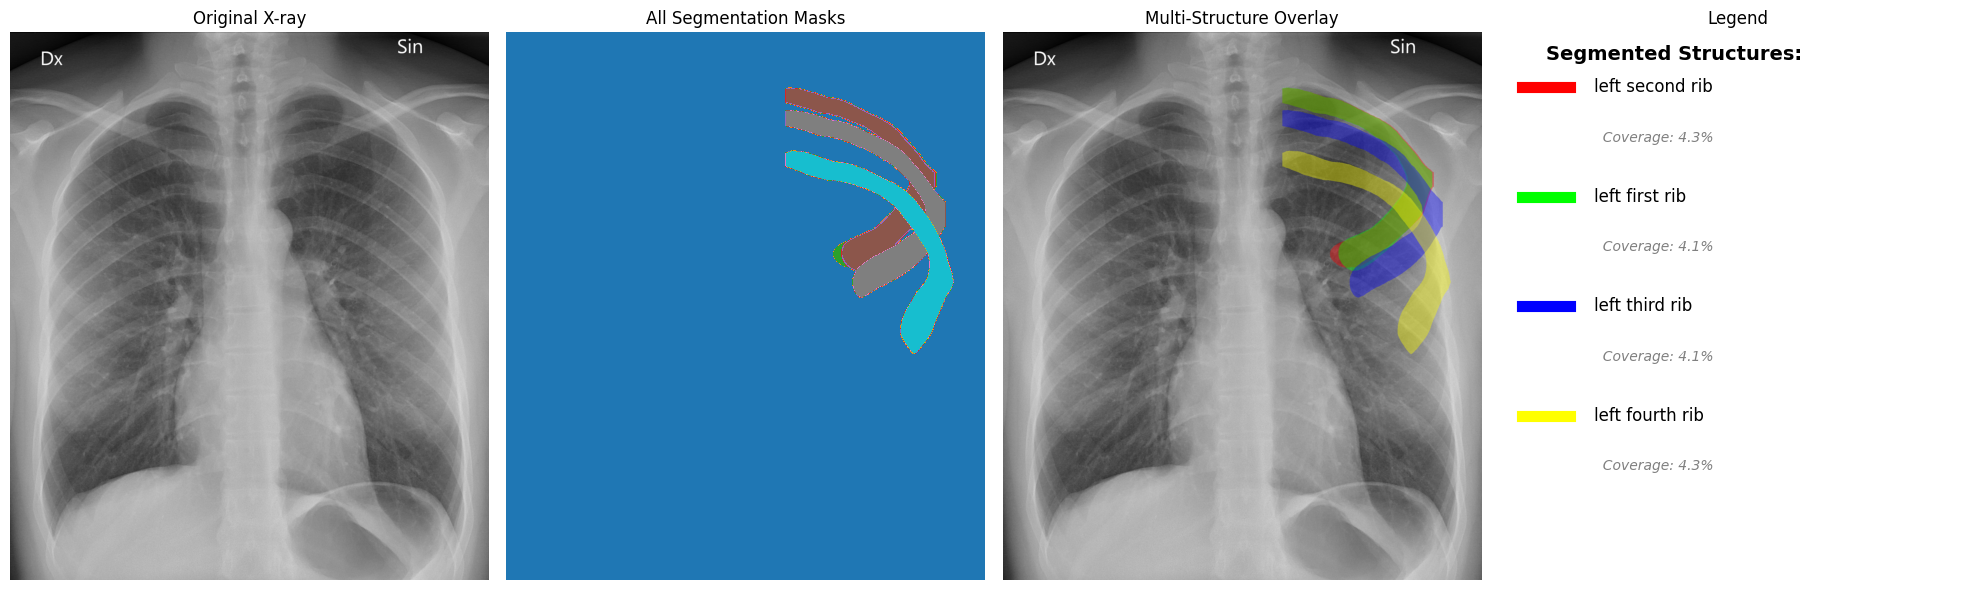

✅ Successfully visualized multi-structure segmentation!
Total structures segmented: 4
  - left second rib
  - left first rib
  - left third rib
  - left fourth rib


In [33]:
# Process multi-structure segmentation results
try:
    # Check if the result contains multiple structure responses (separated by semicolons)
    if ';' in result and 'seg' in result:
        print("Detected multi-structure segmentation response!")
        print(f"Original result: {result}")
        
        # Split the result by semicolons to get individual structure responses
        structure_responses = [resp.strip() for resp in result.split(';')]
        print(f"Found {len(structure_responses)} structure responses")
        
        # Process each structure response separately
        all_masks = []
        structure_info = []
        
        for i, response in enumerate(structure_responses):
            print(f"\nProcessing structure {i+1}: {response}")
            
            # Extract location and segmentation tokens for this structure
            loc_matches = re.findall(r'<loc(\d{4})>', response)
            seg_matches = re.findall(r'<seg(\d+)>', response)
            
            if loc_matches and seg_matches:
                # Reconstruct tokens for this structure
                tokens = ""
                for loc in loc_matches:
                    tokens += f"<loc{loc}>"
                for seg in seg_matches:
                    tokens += f"<seg{seg}>"
                
                # Extract structure name (text after the tokens)
                text_after_tokens = re.sub(r'<[^>]+>', '', response).strip()
                structure_name = text_after_tokens if text_after_tokens else f"Structure {i+1}"
                
                print(f"  Structure name: {structure_name}")
                print(f"  Tokens: {tokens}")
                
                try:
                    # Extract mask for this structure
                    width, height = raw_image.size
                    objects = extract_objs(tokens, width, height)
                    
                    for obj in objects:
                        if 'mask' in obj and obj['mask'] is not None:
                            mask = obj['mask']
                            all_masks.append(mask)
                            structure_info.append({
                                'name': structure_name,
                                'mask': mask,
                                'bbox': obj.get('xyxy', None)
                            })
                            print(f"  ✅ Successfully extracted mask for {structure_name}")
                            break
                    else:
                        print(f"  ❌ No valid mask found for {structure_name}")
                        
                except Exception as e:
                    print(f"  ❌ Error extracting mask for {structure_name}: {e}")
        
        # Visualize all masks if we found any
        if all_masks:
            print(f"\n🎨 Visualizing {len(all_masks)} structures with different colors...")
            
            # Define distinct colors for different structures
            colors = [
                [255, 0, 0],      # Red
                [0, 255, 0],      # Green  
                [0, 0, 255],      # Blue
                [255, 255, 0],    # Yellow
                [255, 0, 255],    # Magenta
                [0, 255, 255],    # Cyan
                [255, 165, 0],    # Orange
                [128, 0, 128],    # Purple
                [255, 192, 203],  # Pink
                [165, 42, 42],    # Brown
            ]
            
            # Create visualization
            plt.figure(figsize=(20, 6))
            
            # Original image
            plt.subplot(1, 4, 1)
            plt.imshow(raw_image)
            plt.title("Original X-ray")
            plt.axis('off')
            
            # Individual masks
            plt.subplot(1, 4, 2)
            combined_mask = np.zeros_like(all_masks[0])
            for i, (mask, info) in enumerate(zip(all_masks, structure_info)):
                # Assign different values to different structures
                mask_binary = mask > 0.3
                combined_mask[mask_binary] = (i + 1) * 50  # Different intensity for each structure
            
            plt.imshow(combined_mask, cmap='tab10', vmin=0, vmax=len(all_masks)*50)
            plt.title("All Segmentation Masks")
            plt.axis('off')
            
            # Overlay on original image
            plt.subplot(1, 4, 3)
            img_np = np.array(raw_image).astype(float)
            
            # Apply each mask with different color and transparency
            for i, (mask, info) in enumerate(zip(all_masks, structure_info)):
                color = colors[i % len(colors)]
                alpha = 0.4
                mask_threshold = 0.3
                mask_binary = mask > mask_threshold
                
                # Create colored overlay for this structure
                mask_overlay = np.zeros_like(img_np)
                mask_overlay[:, :, 0] = color[0]
                mask_overlay[:, :, 1] = color[1] 
                mask_overlay[:, :, 2] = color[2]
                
                # Blend with image
                for c in range(3):
                    img_np[:, :, c] = np.where(
                        mask_binary,
                        (1 - alpha) * img_np[:, :, c] + alpha * mask_overlay[:, :, c],
                        img_np[:, :, c]
                    )
            
            img_np = np.clip(img_np, 0, 255).astype(np.uint8)
            plt.imshow(img_np)
            plt.title("Multi-Structure Overlay")
            plt.axis('off')
            
            # Legend showing structure names and colors
            plt.subplot(1, 4, 4)
            plt.axis('off')
            legend_y = 0.9
            plt.text(0.1, 0.95, "Segmented Structures:", fontsize=14, fontweight='bold')
            
            for i, info in enumerate(structure_info):
                color = colors[i % len(colors)]
                color_norm = [c/255.0 for c in color]  # Normalize for matplotlib
                
                # Create colored rectangle
                plt.plot([0.05, 0.15], [legend_y, legend_y], color=color_norm, linewidth=8)
                plt.text(0.2, legend_y, info['name'], fontsize=12, va='center')
                legend_y -= 0.1
                
                # Add coverage info
                mask_coverage = np.count_nonzero(info['mask']) / info['mask'].size
                plt.text(0.2, legend_y, f"  Coverage: {mask_coverage*100:.1f}%", 
                        fontsize=10, style='italic', color='gray')
                legend_y -= 0.1
            
            plt.xlim(0, 1)
            plt.ylim(0, 1)
            plt.title("Legend")
            
            plt.tight_layout()
            plt.show()
            
            print("✅ Successfully visualized multi-structure segmentation!")
            print(f"Total structures segmented: {len(structure_info)}")
            for info in structure_info:
                print(f"  - {info['name']}")
            
        else:
            print("❌ No valid masks found in multi-structure response")
            
    else:
        print("Not a multi-structure response (no semicolons found or no segmentation tokens)")
        
except Exception as e:
    print(f"Error processing multi-structure segmentation: {e}")
    import traceback
    traceback.print_exc()

In [8]:
results

{'chexanatomy_paligemma_testrun_10B_448_H100': {'segment heart': None,
  'segment right first rib': None,
  'segment right scapula': None,
  'segment left clavicle': None,
  'segment right atrium': None,
  'segment stomach': None},
 'chexanatomy_paligemma_testrun_10B_448_H100_single_structure': {'segment heart': None,
  'segment right first rib': None,
  'segment right scapula': None,
  'segment left clavicle': None,
  'segment right atrium': None,
  'segment stomach': None},
 'chexanatomy_paligemma_testrun_10B_448_H100_single_structure_det_seg': {'segment heart': None,
  'segment right first rib': None,
  'segment right scapula': None,
  'segment left clavicle': None,
  'segment right atrium': None,
  'segment stomach': None},
 'chexanatomy_paligemma_testrun_10B_448_H100_single_structure_tightBBox': {'segment heart': None,
  'segment right first rib': None,
  'segment right scapula': None,
  'segment left clavicle': None,
  'segment right atrium': None,
  'segment stomach': None},
 'c

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_segmentation(results, raw_image):
    all_prompts = set()
    for model_results in results.values():
        all_prompts.update(model_results.keys())
    all_prompts = list(all_prompts)

    for prompt in all_prompts:
        overlays = []
        model_names = []
        for model_name, model_results in results.items():
            # Remove prefix for display
            display_name = model_name.replace("chexanatomy_paligemma", "")
            decoded = model_results.get(prompt)
            mask = None
            if decoded and decoded[0] is not None:
                result = decoded[0]
                try:
                    import re
                    from utils.VQVAE_decoder_utils import extract_objs
                    loc_matches = re.findall(r'<loc(\d{4})>', result)
                    seg_matches = re.findall(r'<seg(\d+)>', result)
                    if seg_matches:
                        reconstructed_tokens = "".join([f"<loc{loc}>" for loc in loc_matches]) + "".join([f"<seg{seg}>" for seg in seg_matches])
                        width, height = raw_image.size
                        segmentation_objects = extract_objs(reconstructed_tokens, width, height)
                        for obj in segmentation_objects:
                            if 'mask' in obj and obj['mask'] is not None:
                                mask = obj['mask']
                                break
                except Exception as e:
                    print(f"Error processing segmentation for {model_name} - {prompt}: {e}")
            if mask is not None:
                mask_display = (mask * 255).astype(np.uint8)
                overlay = np.array(raw_image).copy()
                cmap = plt.get_cmap('jet')
                colored_mask = cmap(mask_display/255.0)[..., :3] * 255
                alpha = 0.4
                overlay = overlay.astype(float)
                overlay = (1 - alpha) * overlay + alpha * colored_mask
                overlay = np.clip(overlay, 0, 255).astype(np.uint8)
                overlays.append(overlay)
                model_names.append(display_name)
            else:
                overlays.append(None)
                model_names.append(display_name)
        n_models = len(overlays)
        fig, axes = plt.subplots(1, n_models+1, figsize=(4*(n_models+1), 4), constrained_layout=True)
        #fig.suptitle(f"Prompt: {prompt}", fontsize=16, y=0.98)
        axes[0].imshow(raw_image)
        axes[0].set_title("Original X-ray", fontsize=12)
        axes[0].axis('off')
        for i, (overlay, name) in enumerate(zip(overlays, model_names)):
            ax = axes[i+1]
            if overlay is not None:
                ax.imshow(overlay)
                ax.set_title(f"{name}", fontsize=12)
            else:
                ax.imshow(raw_image)
                ax.set_title(f"{name}\n(No mask)", fontsize=12)
            ax.axis('off')
        plt.show()

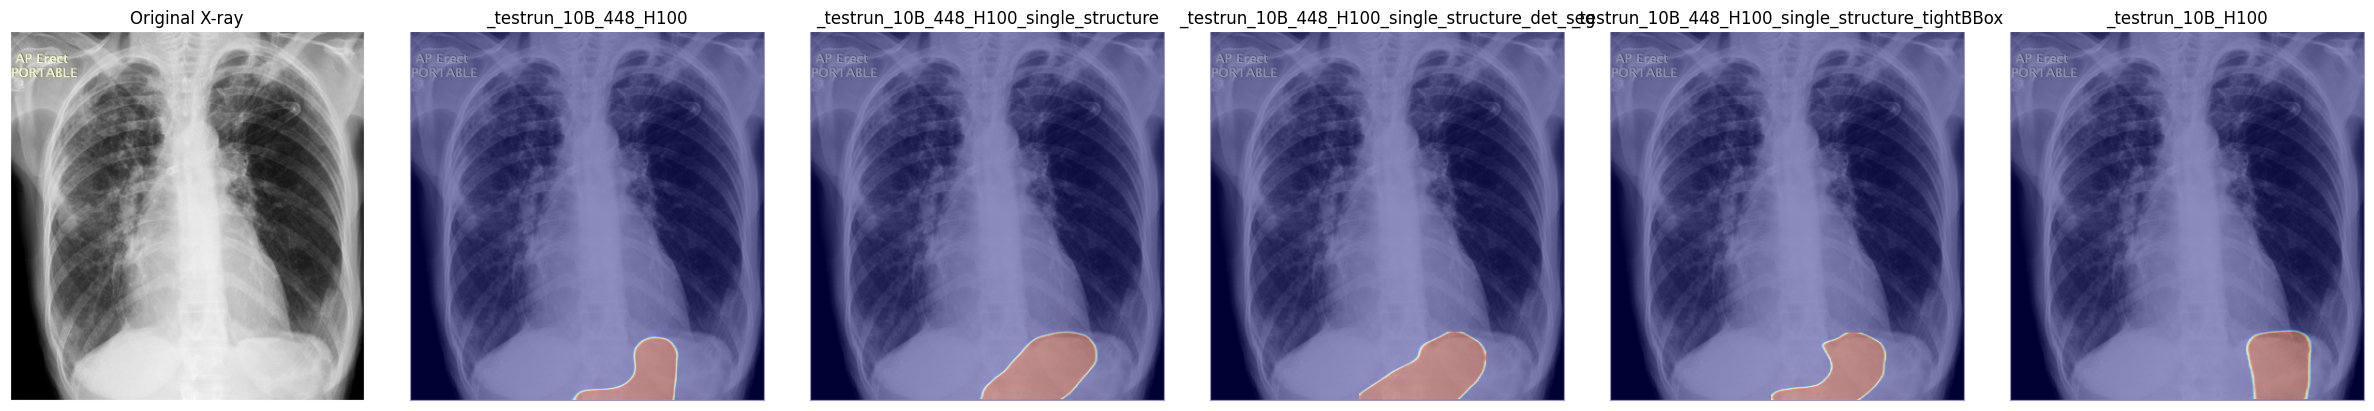

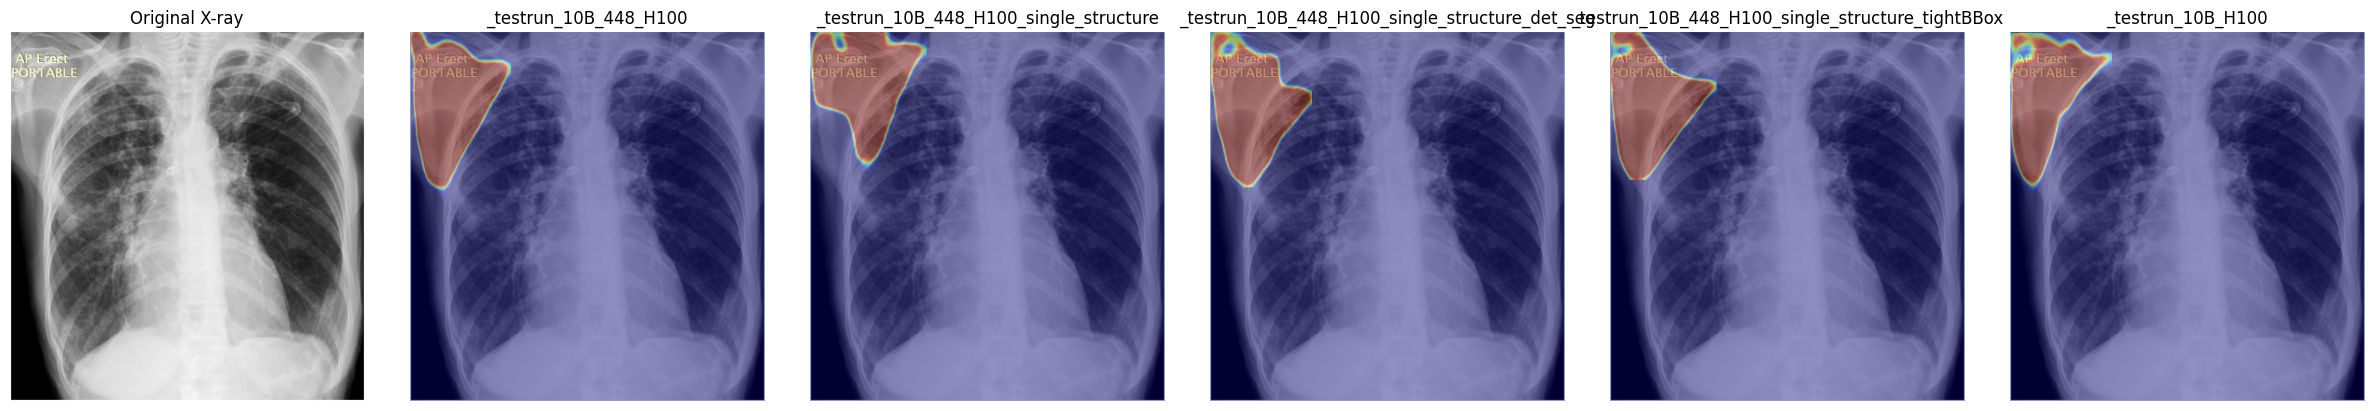

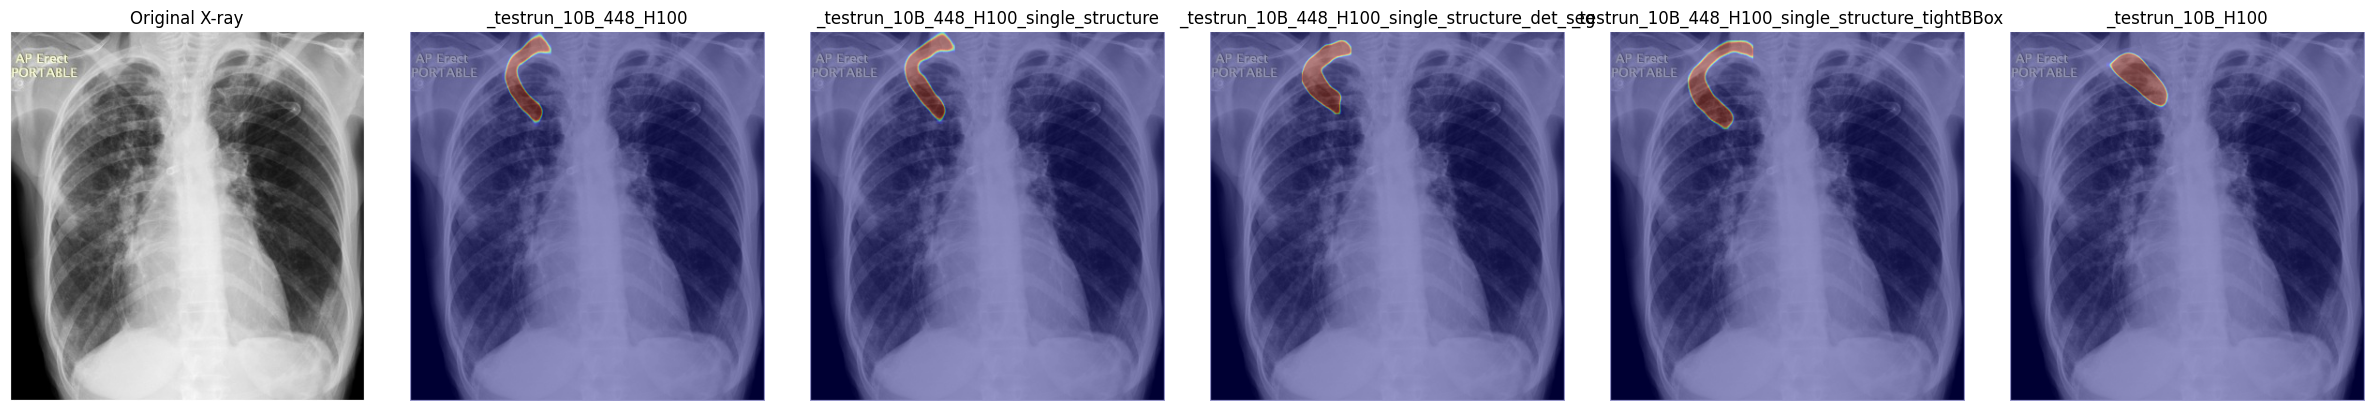

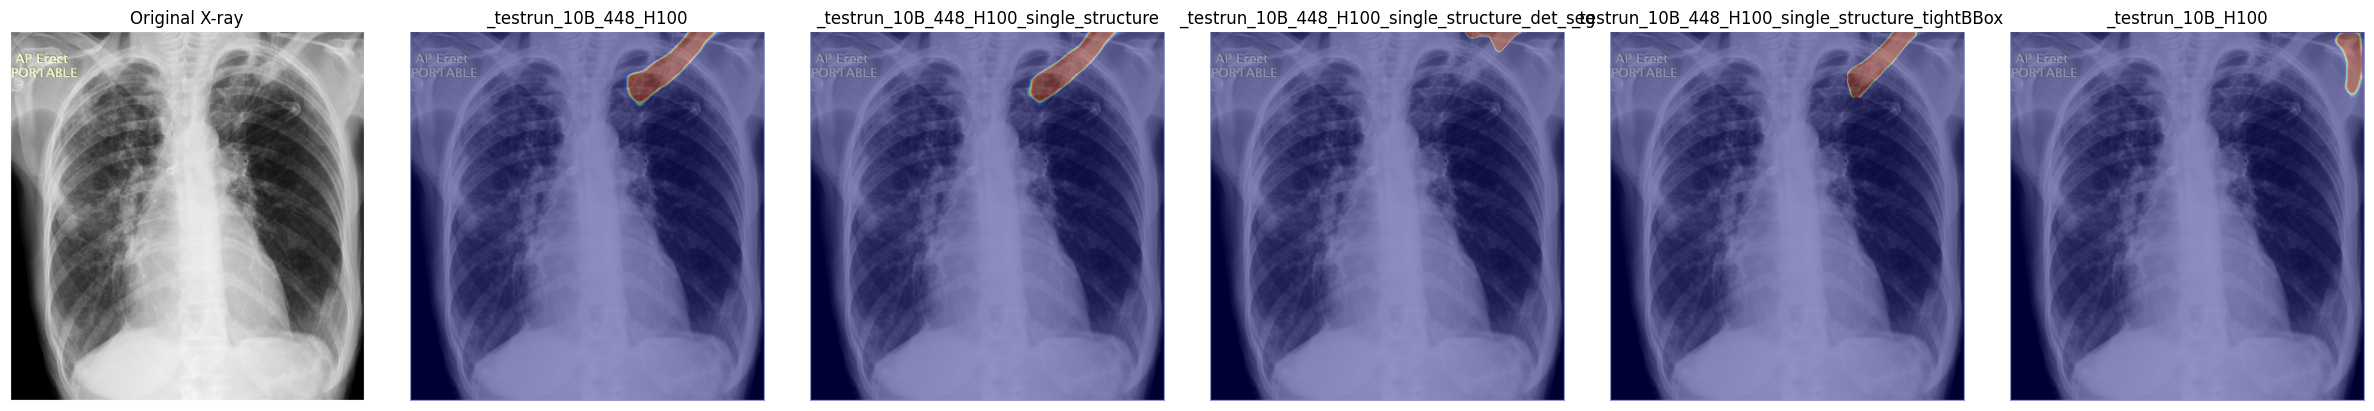

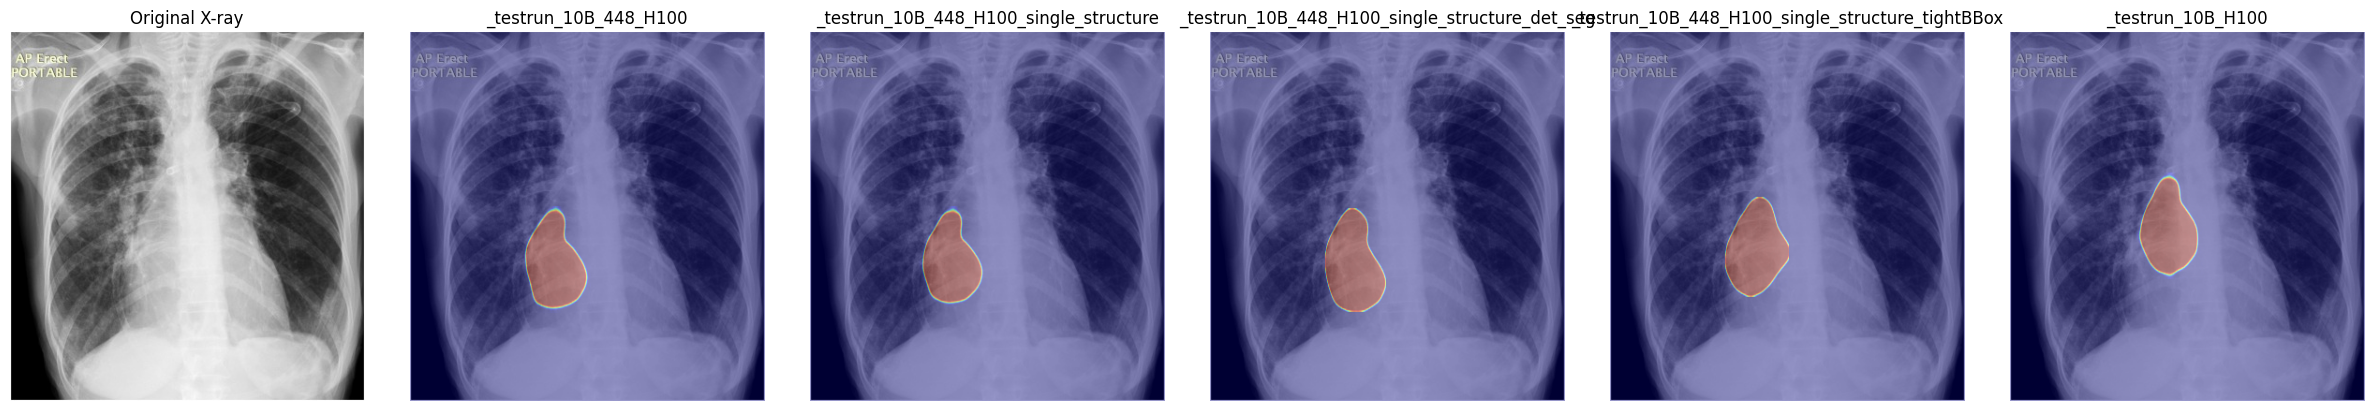

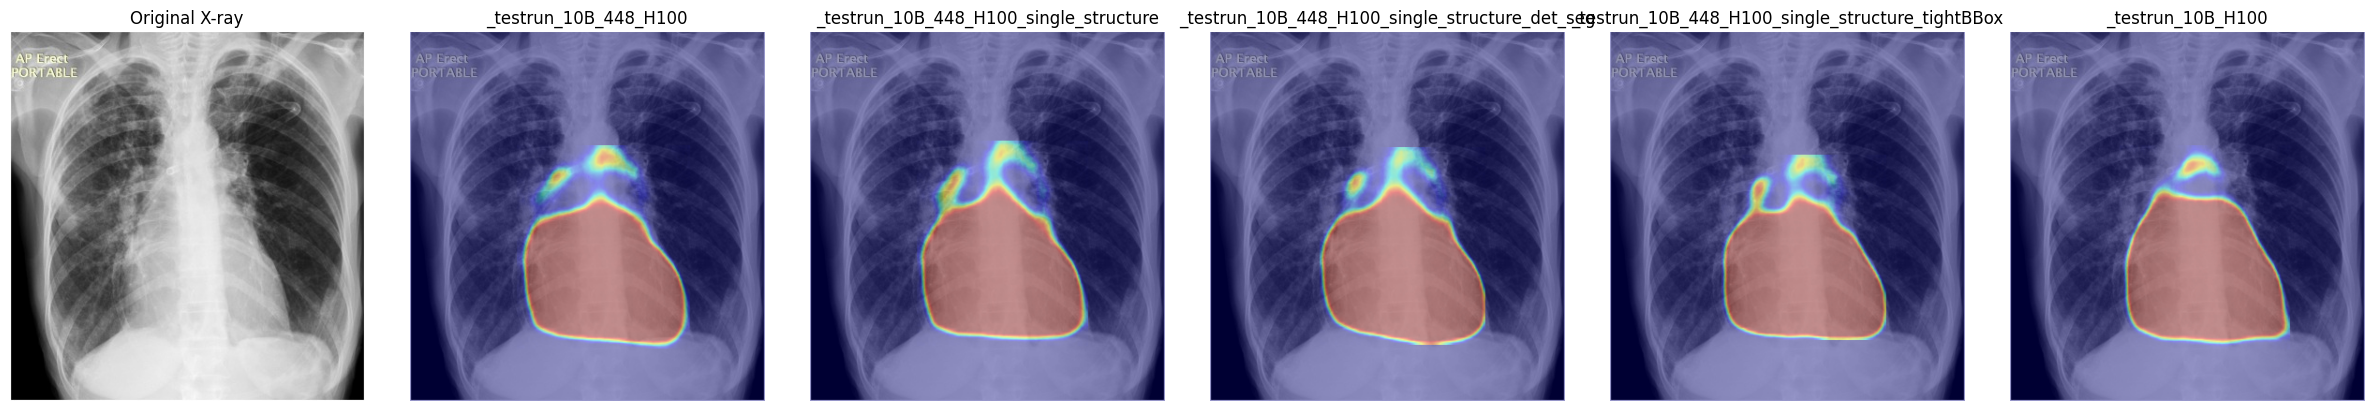

In [22]:
# Call the visualization function to display segmentation results for all models and prompts
visualize_segmentation(results, raw_image)